# Hypothesis Testing

#### Null Hypothesis : H0 or H-naught 
* ##### A = B

#### Alternative Hypothesis : Ha or H1
* ##### A!= B

### Choose level of significance($\alpha$):
* ##### left-tailed - used when downgrading
* ##### right-tailed - used when upgrading
* ##### two-tailed - used when not sure
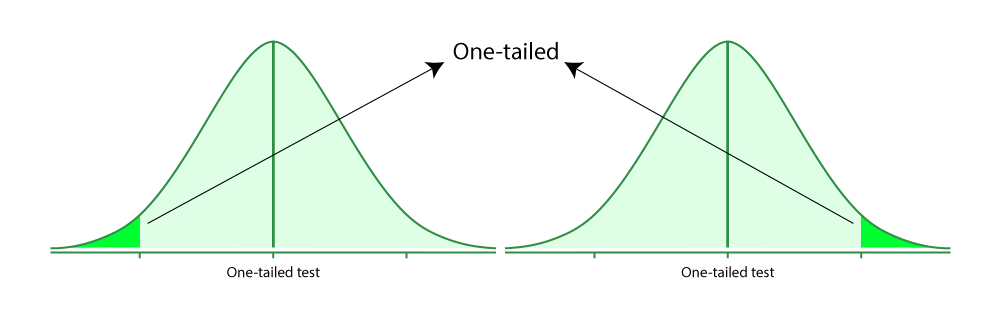

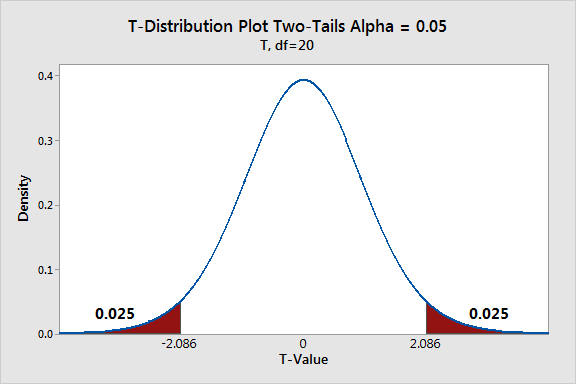

### 3 Types of Testing: 

* ##### Z-test : mean and std of population data, sample data size >= 30, sample data mean
* ##### T-test : population data mean, sample data std, sample size < 30, sample data mean
* ##### Chi-Square-test : Works on goodness

## Z-test:

$$Z = \frac{\bar{x} - \mu}{\sigma / \sqrt{n}}$$

Example:

A teacher claims that the mean score of students in his class is greater than 82 with a standard deviation of 20. If a sample of 81 students was selected with a mean score of 90.


- H0 -> mean is 82
- HA -> mean is not 82

In [1]:
import numpy as np
import scipy.stats as st

In [2]:
pop_std = 20
pop_u = 82
n = 81
sample_x = 90
alpha = 0.05

In [8]:
z_table = st.norm.ppf(1 - alpha)
z_table

np.float64(1.6448536269514722)

In [6]:
z_calc = (sample_x - pop_u)/(pop_std/np.sqrt(n))
z_calc

np.float64(3.5999999999999996)

In [9]:
if z_calc > z_table:
    print("H1 is right")
else:
    print("H0 is right")

H1 is right


Example:

Imagine you work for an e-commerce company, and your team is responsible for analyzing customer purchase data. You want to determine whether a new website design has led to a significant increase in the average purchase amount compared to the old design

Data: You have collected data from a random sample of 30 customers who made purchases on the old website deisgn and 30 customers who made purchases on the new website design you have the sample mean, sample standard deviations, and sample sizes for both groups

- H0 -> Purchases are same
- HA -> Purchases are increased

In [12]:
old_data = np.array([45.2, 42.8, 38.9, 43.5, 41.0, 44.5, 40.5, 42.7, 39.8, 41.4, 44.3, 39.7, 42.1, 40.6, 43.0, 42.2, 41.5, 39.6, 44.0, 43.1, 38.7, 43.9, 42.0, 41.9, 42.8, 43.7, 41.3, 40.9, 42.5, 41.6])
new_data = np.array([48.5, 49.1, 50.2, 47.8, 48.7, 49.9, 48.0, 50.5, 49.8, 49.6, 48.2, 48.9, 49.7, 50.3, 49.4, 50.1, 48.6, 48.3, 49.0, 50.0, 48.4, 49.3, 49.5, 48.8, 50.6, 50.4, 48.1, 49.2, 50.7, 50.8])
pop_std = 2.5
n_sp = 30

In [ ]:
mean_new = new_data.mean()
mean_old = old_data.mean()

In [15]:
z_cal = (mean_new - mean_old) / (pop_std/np.sqrt(n_sp))
z_cal

np.float64(16.11764912551868)

In [16]:
z_table = st.norm.ppf(1 - alpha)
z_table

np.float64(1.6448536269514722)

In [17]:
if z_cal > z_table:
    print("HA is right")
else:
    print("H0 is right")

HA is right


## T-Test:

Conditions :

- data->Normal Distribution(assumption)
- Mean of Population data
- Mean and STD of sample data
- No of sample < 30


$$T = \frac{\bar{x} - \mu}{\text{S} / \sqrt{n}}$$

Example:

A manufacturer claims that the average weight of a bag of potato chips is 150 grams. A sample of 25 bags is taken, and the average weight is found to be 148 grams, with a standard deviation of 5 grams. Test the manufacturer's claim using a one-tailed t-test with a significance level of 0.05


- H0 -> u = 150gm
- H1 -> u < 150gm

In [ ]:
pop_u = 150
sam_x = 148
n = 25
sam_std = 5
alpha = 0.05

In [38]:
df = n - 1 # df = degree of freedom

t_table = st.t.ppf(alpha, df)
t_table

np.float64(-1.7108820799094284)

In [39]:
t_calc = (sam_x - pop_u)/(sam_std/np.sqrt(n))
t_calc

np.float64(-2.0)

In [40]:
if t_calc < t_table:
    print("H1 is right")
else:
    print("H0 is right")

H1 is right


Example 2:

A company wants to test whether there is a difference in productivity between two teams. They randomly select 20 employees from each team and record their productivity scores. The mean productivity score for Team A is 80 with a standard deviation of 5, while the mean of productivity score for Team B is 75 with a standard deviation of 6. Test at a 5% level of significance whether there is a difference of productivity between the two teams.

- H0 -> No difference
- H1 -> Difference

$$
t = \frac{(\bar{x}_1 - \bar{x}_2) - (\mu_1 - \mu_2)}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}
$$


In [47]:
A_mean = 80
A_std = 5

B_mean = 75
B_std = 6

n = 20
alpha = 0.05
alpha_dist = alpha/2
df = n+n-2

In [49]:
t_table = st.t.ppf(1 - alpha_dist, df)
t_table

np.float64(2.0243941639119694)

In [52]:
t_calc = (A_mean - B_mean)/np.sqrt((A_std**2 / n) + (B_std**2 / n))
t_calc

np.float64(2.862991671569341)

In [53]:
if abs(t_calc) > abs(t_table):
    print("HA is right")
else:
    print("H0 is right")

HA is right


Example 3:
A company wants to test whether a new training program imporves the typing speed of its employees. The typing speed of 20 employees was recorded before and after the training. The data is given below. Test at a 5% level of significance whether the training program has an effect on the typing speed of the employees.

- H0 -> No improvement
- H1 -> Improvement

In [63]:
before_data = np.array([50,60,45,65,55,70,40,75,80,65,70,60,50,55,45,75,60,50,65,70])
after_data = np.array([60,70,55,75,65,80,50,85,90,70,75,65,55,60,50,80,65,55,70,75])
n = 20
df = n-1 #employees are same for both the data so only 1 times counted

alpha = 0.05
alpha_dist = alpha/2

A_mean = np.mean(after_data)
B_mean = np.mean(before_data)


In [64]:
t_table = st.t.ppf(alpha_dist, df)
t_table

np.float64(-2.0930240544083096)

In [65]:
t_calc = (A_mean - B_mean)/np.sqrt((after_data.std()**2/n) + (before_data.std()**2/n))
t_calc

np.float64(2.061200527128206)

In [66]:
if abs(t_calc) > abs(t_table):
    print("H1 is right")
else:
    print("H0 is right")

H0 is right


### Chi Square Test:

- ##### Goodness determination
- ##### Independence determination

$$\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$$

$\chi^2$ - chi squared 

$O_i$ - observed value

$E_i$ - expected value

Example 1:

A fair die is rolled 120 times and the following results are obtained:

Face 1: 22 times

Face 2: 17 times

Face 3: 20 times

Face 4: 26 times

Face 5: 22 times

Face 6: 13 times

Test at a 5% level of significance whether the die is fair

- H0 die is fair
- H1 die is unfair

In [74]:
ob = np.array([22,17,20,26,22,13])
ex = np.array([20 for i in range(0, 6)])
chi_table = 11.07

In [73]:
chi_calc = np.sum(np.square(ob-ex)/ex)
chi_calc

np.float64(5.1000000000000005)

In [76]:
if chi_calc > chi_table:
    print("H1 is right")
else:
    print("H0 is right")

H0 is right


Example 2:

A study was conducted to investigate whether there is a relationship between gender and the preferred genre of music. A sample of 235 people was selected, and the data collected is shown below. Test at a 5% level of significance whether there is a significant association between gender and music preference.

- H0 -> No relationship/association
- H1 -> Relationship/association

df = (row - 1)(col - 1) -> 3

In [ ]:
chi_table = 7.815
male = np.array([40,45,25,10])
female = np.array([35,30,20,30])

sumR1 = np.sum(male)
sumR2 = np.sum(female)
sum_row = np.array([sumR1, sumR2])
sum_row

array([120, 115])

In [82]:
sum_col = male + female
sum_col

array([75, 75, 45, 40])

In [84]:
exp = []
for i in sum_row:
    for j in sum_col:
        value = (i*j)/235
        exp.append(value)

In [85]:
obj = np.array([40,45,25,10,35,30,20,30])
obj

array([40, 45, 25, 10, 35, 30, 20, 30])

In [ ]:
chi_calc = np.sum(np.square(obj - exp) / exp)

(np.float64(13.788747987117553), 7.815)

In [89]:
if chi_calc > chi_table:
    print("H1 is right")
else:
    print("H0 is right")

H1 is right
